In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
N = 5000

df = pd.DataFrame({
    "company_id": [f"C-{i:04d}" for i in range(N)],
    "contract_months": np.random.randint(1, 36, N),
    "monthly_fee": np.random.randint(5000, 100000, N),
    "active_users_ratio": np.round(np.random.uniform(0.1, 1.0, N), 2),
    "login_freq_per_week": np.round(np.random.uniform(0.5, 14.0, N), 1),
    "feature_usage_score": np.round(np.random.uniform(0.0, 1.0, N), 2),
    "support_tickets_90d": np.random.randint(0, 20, N),
    "nps_score": np.random.randint(0, 11, N),
    "payment_delays_count": np.random.randint(0, 5, N),
})

# churnルール埋め込み
churn_score = (
    (df["active_users_ratio"] < 0.3).astype(int) * 2 +
    (df["login_freq_per_week"] < 2.0).astype(int) * 2 +
    (df["feature_usage_score"] < 0.2).astype(int) * 1 +
    (df["nps_score"] <= 3).astype(int) * 2 +
    (df["payment_delays_count"] >= 2).astype(int) * 1 +
    (df["support_tickets_90d"] >= 10).astype(int) * 1
)

churn_prob = 1 / (1 + np.exp(-(churn_score - 3)))
df["churned"] = (np.random.uniform(0, 1, N) < churn_prob).astype(int)

print(df.shape)
print(df["churned"].value_counts())
df.head()

(5000, 10)
churned
0    2856
1    2144
Name: count, dtype: int64


,company_id,contract_months,monthly_fee,active_users_ratio,login_freq_per_week,feature_usage_score,support_tickets_90d,nps_score,payment_delays_count,churned
0,C-0000,29,36186,0.31,8.6,0.39,11,8,4,0
1,C-0001,15,31928,0.32,4.2,0.80,7,4,4,1
2,C-0002,8,88087,0.44,3.9,0.98,1,8,3,0
3,C-0003,21,92029,0.31,13.7,0.39,8,4,0,0
4,C-0004,19,25711,0.60,12.1,0.85,15,3,2,1


In [4]:
from sklearn.model_selection import train_test_split

# 特徴量とターゲット分離
feature_cols = [
    "contract_months", "monthly_fee", "active_users_ratio",
    "login_freq_per_week", "feature_usage_score",
    "support_tickets_90d", "nps_score", "payment_delays_count"
]

X = df[feature_cols]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate:  {y_test.mean():.3f}")

# CSV保存
df.to_csv("customers.csv", index=False)
print("customers.csv 保存完了")

Train: (4000, 8), Test: (1000, 8)
Train churn rate: 0.429
Test churn rate:  0.429
customers.csv 保存完了


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import joblib
import json

# スケーリング
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# モデル学習
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# 評価
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.4f}")
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

AUC: 0.7615

--- Confusion Matrix ---
[[456 115]
 [186 243]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       571
           1       0.68      0.57      0.62       429

    accuracy                           0.70      1000
   macro avg       0.69      0.68      0.68      1000
weighted avg       0.70      0.70      0.69      1000



In [6]:
import joblib
import json

# モデル保存
joblib.dump(model, "model.joblib")

# 特徴量カラム保存
with open("feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

print("model.joblib 保存完了")
print("feature_columns.json 保存完了")

model.joblib 保存完了
feature_columns.json 保存完了


In [7]:
def predict_churn(input_data: dict) -> dict:
    import numpy as np

    # 入力をDataFrameに変換
    input_df = pd.DataFrame([input_data])[feature_cols]
    input_scaled = scaler.transform(input_df)

    # 予測
    prob = model.predict_proba(input_scaled)[0][1]

    # リスクレベル判定
    if prob >= 0.7:
        risk_level = "High"
    elif prob >= 0.4:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    # 主要因子（係数の大きい順）
    coef = model.coef_[0]
    factors = sorted(
        zip(feature_cols, coef * input_scaled[0]),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    top_factors = [
        {"feature": f, "impact": round(float(v), 4)}
        for f, v in factors[:3]
    ]

    # 推奨施策
    actions = []
    if input_data["nps_score"] <= 3:
        actions.append("CSチームによる緊急フォローアップ実施")
    if input_data["login_freq_per_week"] < 2.0:
        actions.append("オンボーディング再実施・活用支援")
    if input_data["payment_delays_count"] >= 2:
        actions.append("請求担当者へエスカレーション")
    if not actions:
        actions.append("定期チェックイン継続")

    return {
        "company_id": input_data.get("company_id", "unknown"),
        "churn_probability": round(float(prob), 4),
        "risk_level": risk_level,
        "top_factors": top_factors,
        "recommended_actions": actions
    }

# テスト実行
sample = {
    "company_id": "C-1042",
    "contract_months": 3,
    "monthly_fee": 15000,
    "active_users_ratio": 0.15,
    "login_freq_per_week": 1.2,
    "feature_usage_score": 0.1,
    "support_tickets_90d": 12,
    "nps_score": 2,
    "payment_delays_count": 3
}

result = predict_churn(sample)
print(json.dumps(result, ensure_ascii=False, indent=2))

{
  "company_id": "C-1042",
  "churn_probability": 0.8922,
  "risk_level": "High",
  "top_factors": [
    {
      "feature": "active_users_ratio",
      "impact": 0.7226
    },
    {
      "feature": "nps_score",
      "impact": 0.6827
    },
    {
      "feature": "login_freq_per_week",
      "impact": 0.4442
    }
  ],
  "recommended_actions": [
    "CSチームによる緊急フォローアップ実施",
    "オンボーディング再実施・活用支援",
    "請求担当者へエスカレーション"
  ]
}


In [8]:
with open("sample_payload.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print("sample_payload.json 保存完了")

sample_payload.json 保存完了


In [9]:
joblib.dump(scaler, "scaler.joblib")
print("scaler.joblib 保存完了")

scaler.joblib 保存完了


In [10]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# LightGBMモデル学習
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

# 評価
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_prob_lgb)

print(f"LightGBM AUC: {auc_lgb:.4f}")
print(f"Logistic Regression AUC: {auc:.4f}")
print(f"AUC改善: {auc_lgb - auc:.4f}")
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_lgb))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lgb))

LightGBM AUC: 0.7961
Logistic Regression AUC: 0.7615
AUC改善: 0.0345

--- Confusion Matrix ---
[[442 129]
 [137 292]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.77      0.77       571
           1       0.69      0.68      0.69       429

    accuracy                           0.73      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.73      0.73      0.73      1000



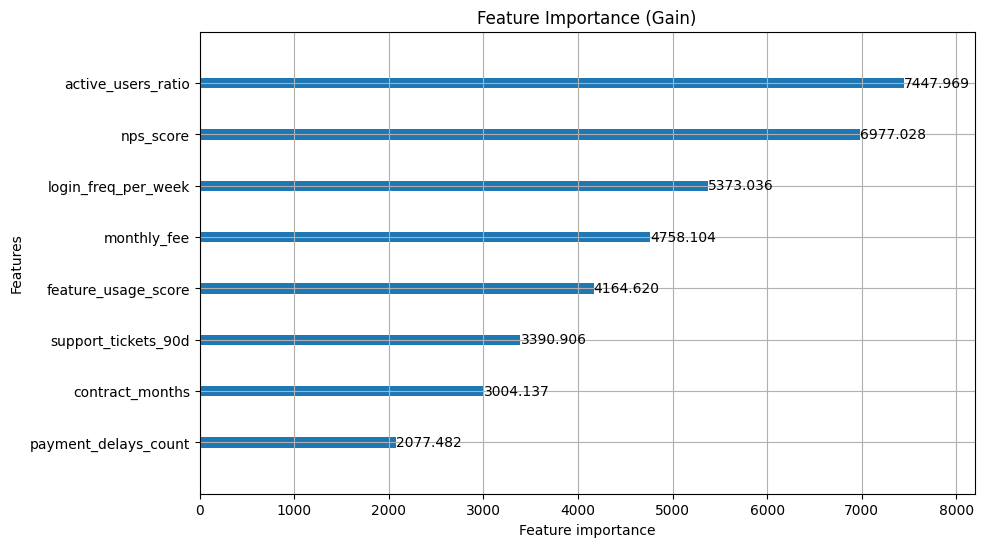

In [11]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# 特徴量の重要度をプロット
lgb.plot_importance(lgb_model, figsize=(10, 6), importance_type='gain')
plt.title('Feature Importance (Gain)')
plt.show()

In [12]:
import optuna.integration.lightgbm as lgb_optuna

# (少しコードが長くなるので、まずは重要度を見てから「次は自動チューニングやりたい」と言ってもらえれば、専用のコードを書きますね！)

In [13]:
import optuna.integration.lightgbm as lgb_optuna
import pandas as pd

# 1. データをOptuna専用の形式に変換
dtrain = lgb_optuna.Dataset(X_train, label=y_train)
dval = lgb_optuna.Dataset(X_test, label=y_test, reference=dtrain)

# 2. パラメータを探す設定
params = {
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
    "boosting_type": "gbdt",
}

# 3. 最適化スタート（少し時間がかかります）
best_model = lgb_optuna.train(
    params,
    dtrain,
    valid_sets=[dtrain, dval],
    num_boost_round=1000,
)

# 4. 見つかった最強のパラメータを表示
print("\n--- 最強のパラメータ ---")
print(best_model.params)

[I 2026-04-18 14:36:50,394] A new study created in memory with name: no-name-985e904b-d73f-41b6-9a7d-b8af2b4fa4c5
min_child_samples, val_score: 0.814340: 100%|##########| 5/5 [00:03<00:00,  1.66it/s]


--- 最強のパラメータ ---
{'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'feature_pre_filter': False, 'lambda_l1': 9.762653262335872, 'lambda_l2': 3.9300500868087016, 'num_leaves': 31, 'feature_fraction': 0.7, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 100, 'num_iterations': 1000}


In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# 1. 最強モデルで予測
y_pred_probs = best_model.predict(X_test)
y_pred_best = [1 if p > 0.5 else 0 for p in y_pred_probs]

# 2. スコア表示
print(f"Optuna最強モデル AUC: {roc_auc_score(y_test, y_pred_probs):.4f}")
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_best))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_best))